In [29]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [30]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [31]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [32]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelength')

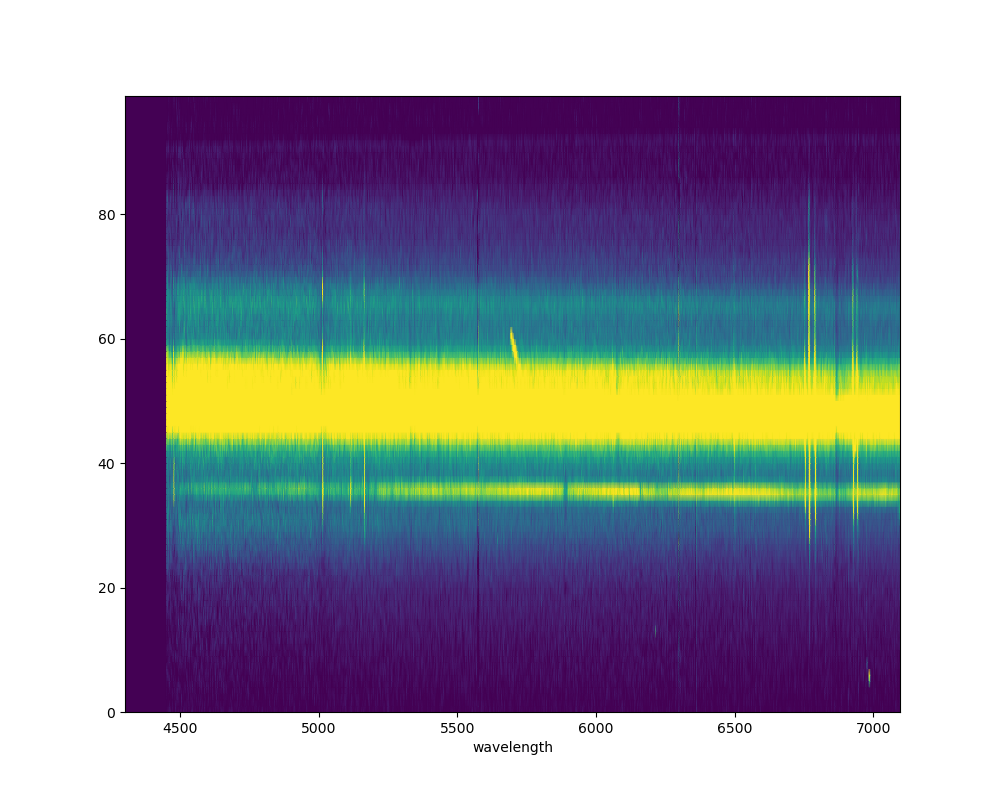

In [33]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [34]:
z = 0.03191
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = 1.984
sigma = seeing / 2.35
n_component = 4

In [35]:
l_HA

6772.425330000001

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

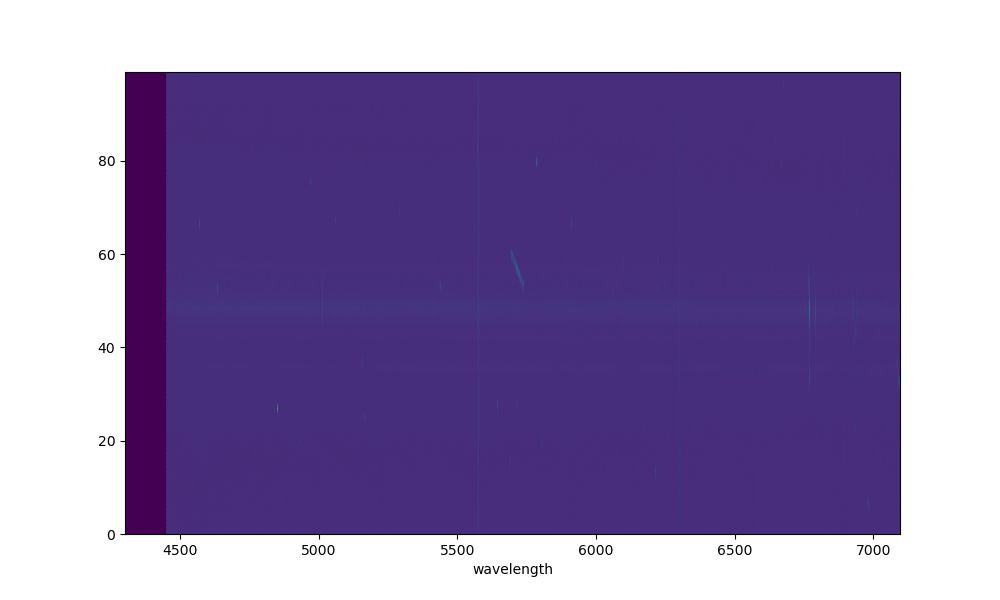

In [36]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[67:167, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

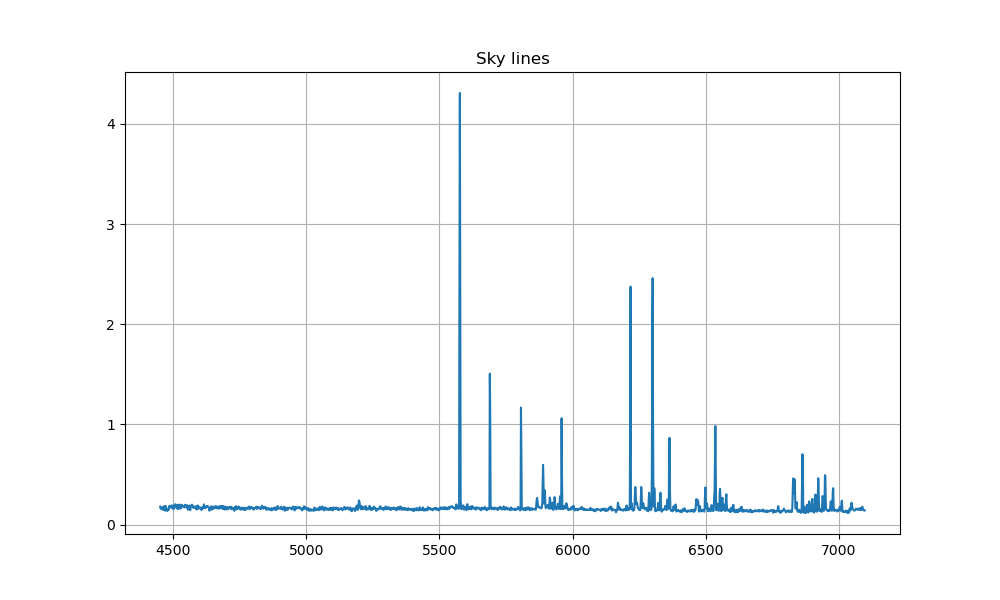

In [37]:
mask_sky = (y > 10)*(y < 20)
mask_wv = wv > 4450.5
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

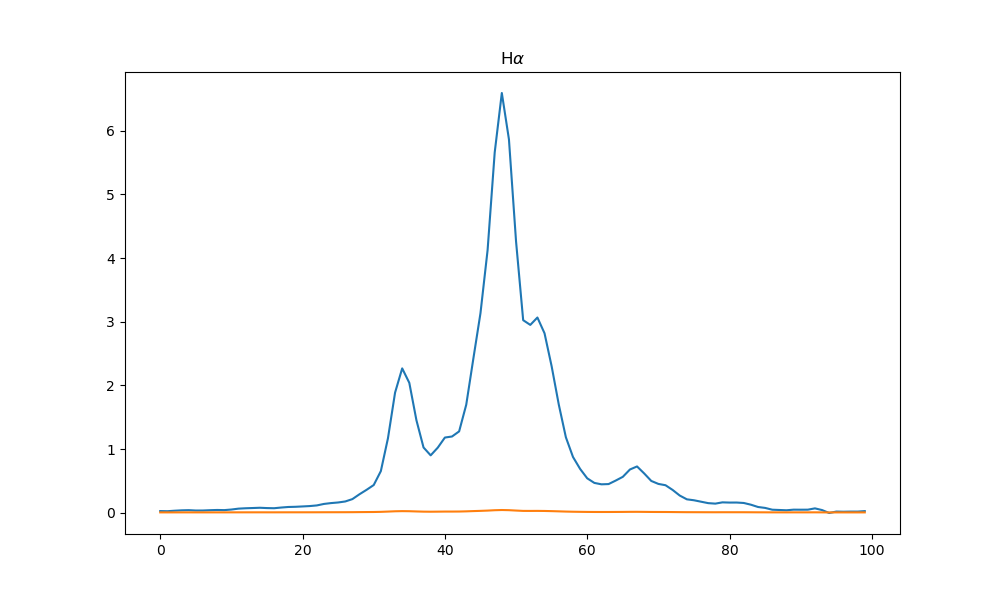

In [38]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [39]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])#+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 10)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 10)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75)   
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [40]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 179.01806109631588
differential_evolution step 2: f(x)= 179.01806109631588
differential_evolution step 3: f(x)= 179.01806109631588
differential_evolution step 4: f(x)= 179.01806109631588
differential_evolution step 5: f(x)= 76.2894045162349
differential_evolution step 6: f(x)= 76.2894045162349
differential_evolution step 7: f(x)= 67.65856052043347
differential_evolution step 8: f(x)= 54.05061998241553
differential_evolution step 9: f(x)= 28.26425042792046
differential_evolution step 10: f(x)= 24.035391160091258
differential_evolution step 11: f(x)= 24.035391160091258
differential_evolution step 12: f(x)= 24.035391160091258
differential_evolution step 13: f(x)= 14.08004495860507
differential_evolution step 14: f(x)= 14.08004495860507
differential_evolution step 15: f(x)= 14.08004495860507
differential_evolution step 16: f(x)= 14.08004495860507
differential_evolution step 17: f(x)= 10.621009794610112
differential_evolution step 18: f(x)= 10.6210097946

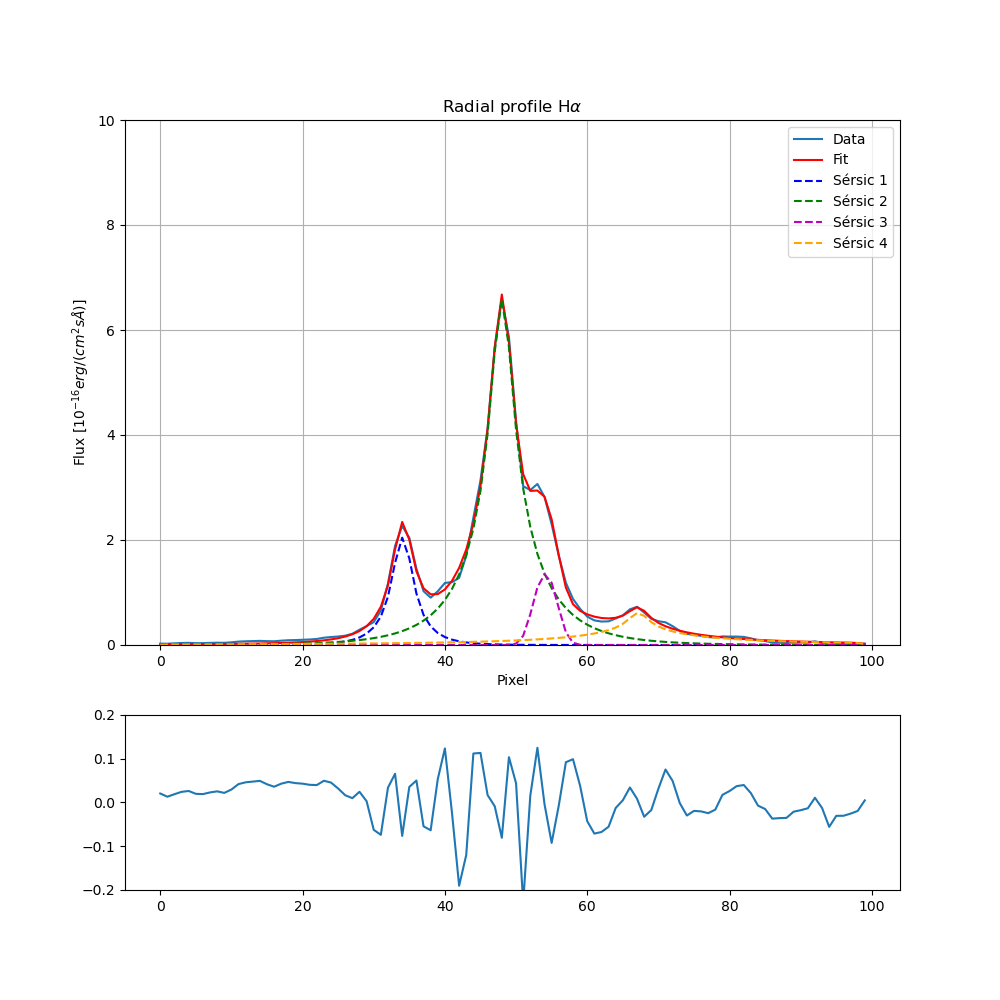

In [41]:
plot_diff(x_axes, best_params, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [45]:
lower_bounds, upper_bounds = zip(*bounds_HA)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA, 
                                           bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA,
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5337, r_e=2.4038, n=1.0109, x_0=34.0353
Sérsic 2: I_e=0.3809, r_e=14.5117, n=1.9113, x_0=47.9434
Sérsic 3: I_e=0.7630, r_e=1.7979, n=0.5319, x_0=53.8585
Sérsic 4: I_e=0.0171, r_e=26.2604, n=2.1757, x_0=67.4571
[1.22518011e-01 3.20832893e-01 1.85014869e-01 6.12324667e-02
 3.80525356e-02 1.03817322e+00 7.56574181e-02 4.82488964e-02
 2.11608180e-01 2.69810974e-01 2.13471359e-01 1.19331193e-01
 1.19202165e-02 1.49753983e+01 5.00103899e-01 2.08952861e-01]
15.413674130292174


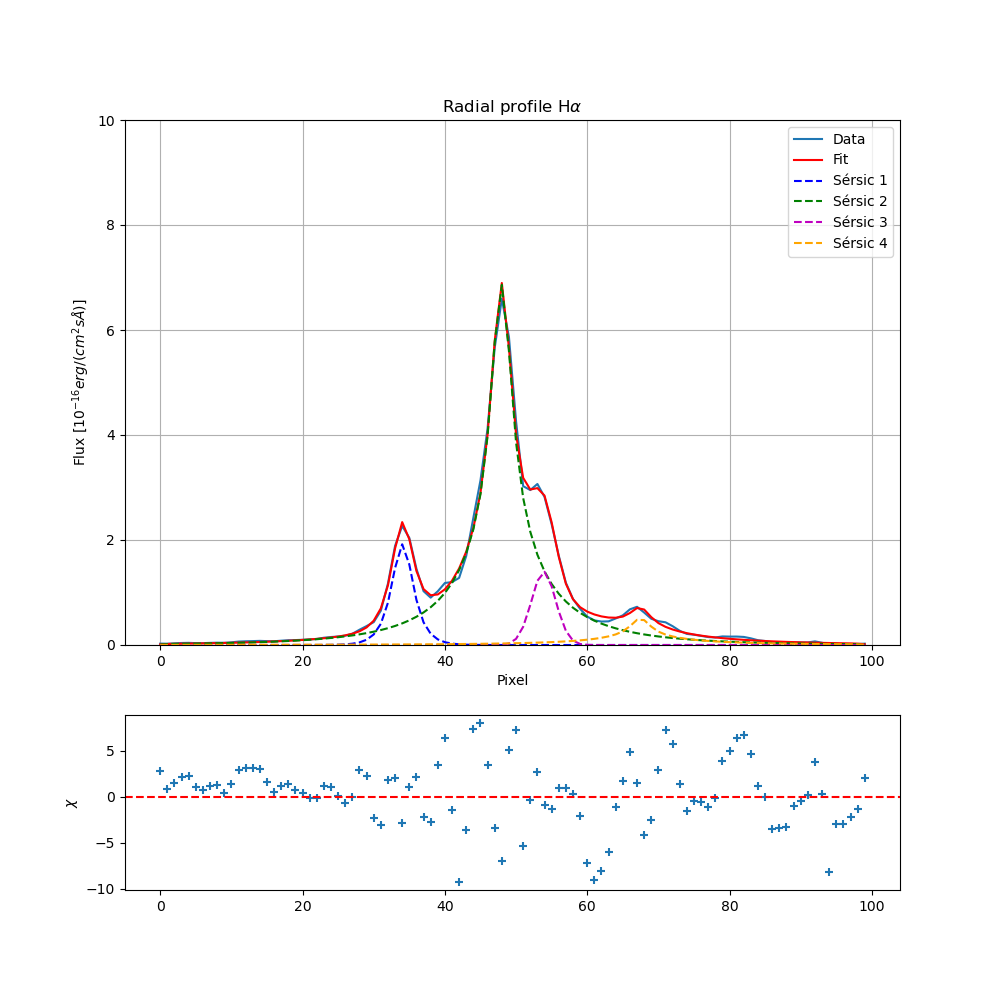

In [46]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [49]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing/2), x_0_HA[0]+(seeing/2)),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-(seeing/2), x_0_HA[1]+(seeing/2)),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-(seeing/2), x_0_HA[2]+(seeing/2)),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-(seeing/2), x_0_HA[3]+(seeing/2))
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

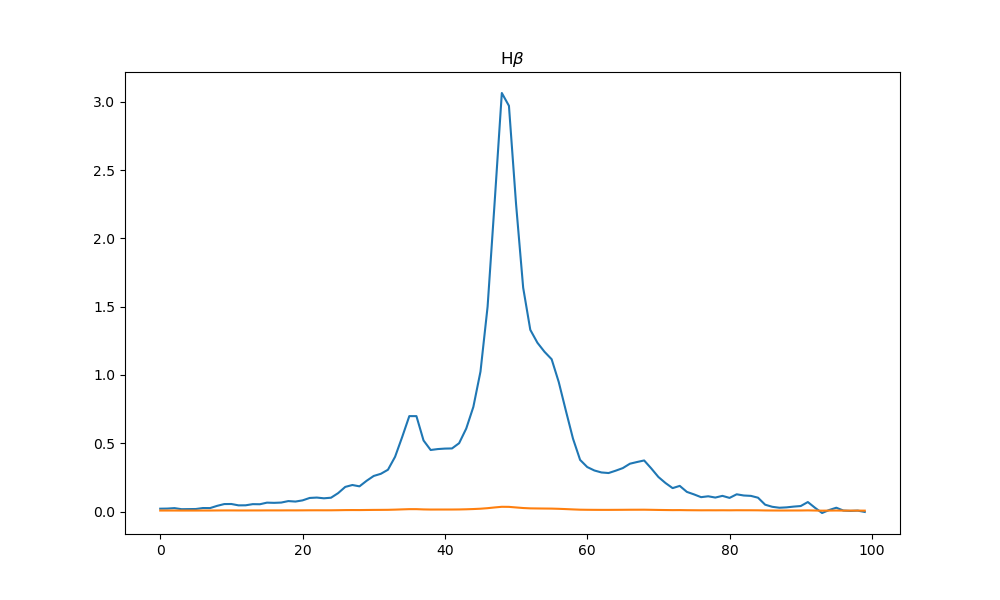

In [50]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [51]:
bounds

[(0, 10),
 (0, 50),
 (0.1, 10),
 (33.0433, 35.0273),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (46.9514, 48.935399999999994),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (52.8665, 54.8505),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (66.46509999999999, 68.4491)]

In [52]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3333.617192739502
differential_evolution step 2: f(x)= 3333.617192739502
differential_evolution step 3: f(x)= 3333.617192739502
differential_evolution step 4: f(x)= 3333.617192739502
differential_evolution step 5: f(x)= 3333.617192739502
differential_evolution step 6: f(x)= 321.93744920963474
differential_evolution step 7: f(x)= 321.93744920963474
differential_evolution step 8: f(x)= 321.93744920963474
differential_evolution step 9: f(x)= 321.93744920963474
differential_evolution step 10: f(x)= 321.93744920963474
differential_evolution step 11: f(x)= 321.93744920963474
differential_evolution step 12: f(x)= 152.06298455156184
differential_evolution step 13: f(x)= 152.06298455156184
differential_evolution step 14: f(x)= 152.06298455156184
differential_evolution step 15: f(x)= 152.06298455156184
differential_evolution step 16: f(x)= 152.06298455156184
differential_evolution step 17: f(x)= 152.06298455156184
differential_evolution step 18: f(x)= 152.062

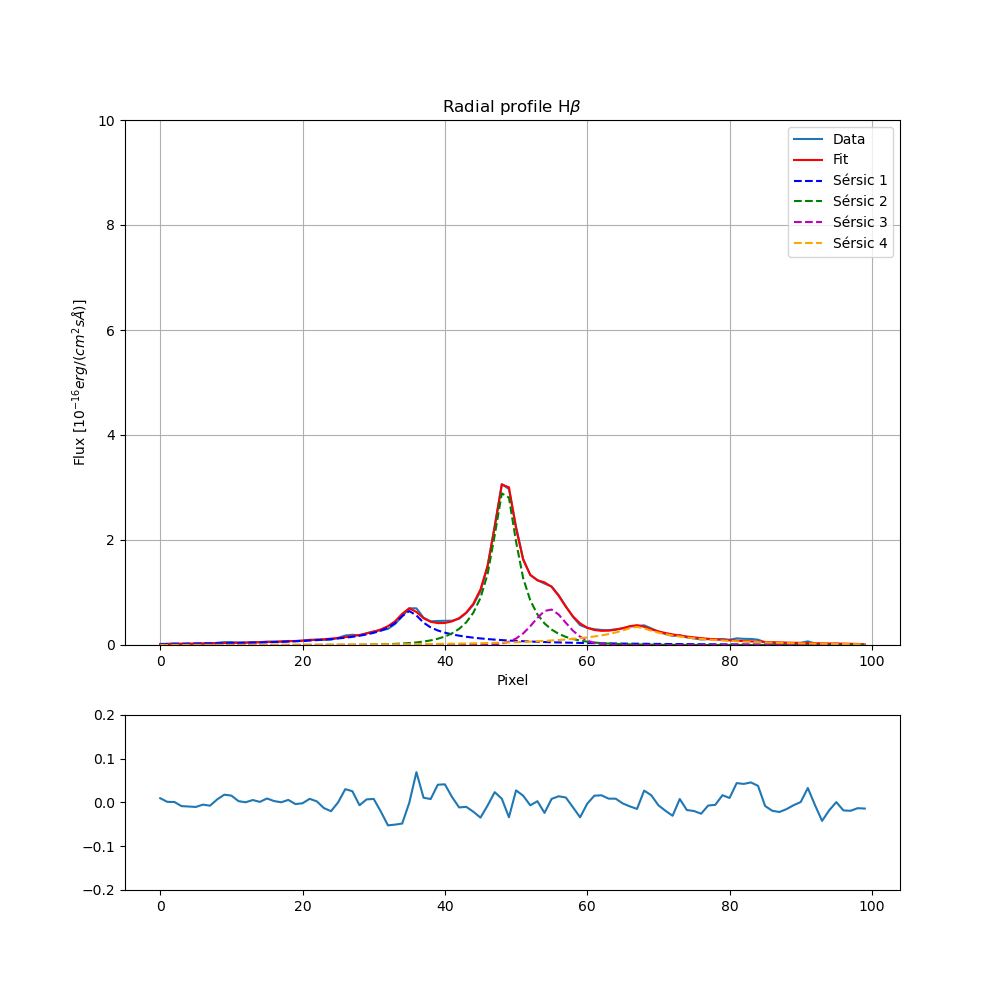

In [53]:
plot_diff(x_axes, best_params, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [54]:
#bounds_new = [
#    (0.5, 1.5),    # I_e: da 0 a 10 (o un valore ragionevole)
#    (0, 50),  # r_e: da 0.1 a 50
#    (0.1, 5),  # n: da 0.1 a 10
#    (35, 40),   # x_0: posizione da 0 a 100
#
#    (0.5, 1.5),
#    (0, 3),
#    (0.1, 4),
#    (45, 50),
#
#    (0, 1.5),
#    (0, 25),
#    (0.1, 5),
#    (76, 85)
#]
#lower_bounds, upper_bounds = zip(*bounds_new)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB) #, bounds = bounds_list)

chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB,
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Sérsic 1: I_e=0.0244, r_e=33.7795, n=2.0544, x_0=35.4014
Sérsic 2: I_e=0.4918, r_e=4.8233, n=1.2713, x_0=48.4293
Sérsic 3: I_e=0.3059, r_e=2.9376, n=0.6179, x_0=54.6959
Sérsic 4: I_e=0.0481, r_e=17.0385, n=1.1969, x_0=66.8386
[1.01977296e-02 1.00975752e+01 3.40716713e-01 7.46703059e-03
 5.79833293e-02 3.84915709e-01 8.77071903e-02 4.18695490e-02
 5.07449103e-02 3.23270789e-01 1.18281212e-01 1.47920700e-01
 9.73229584e-03 2.61017505e+00 1.36573502e-01 2.63683799e-01]
3.6933608518754135


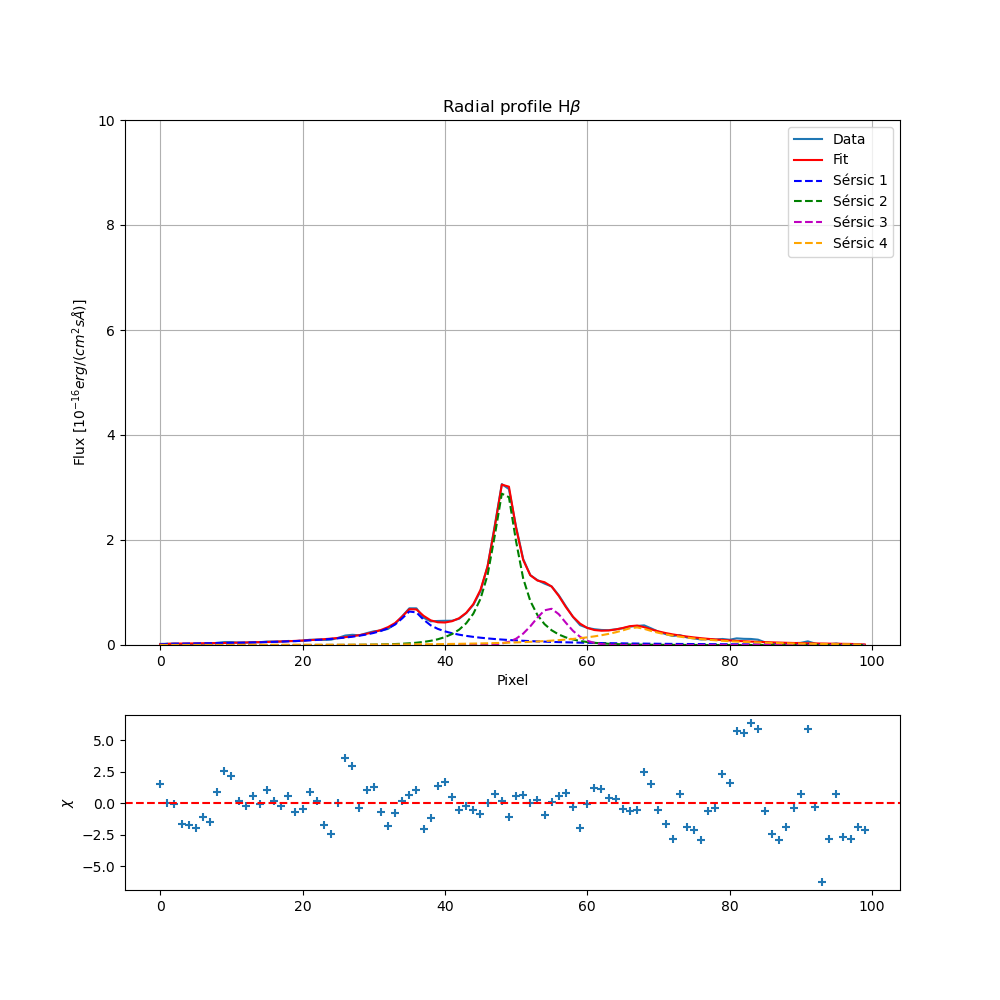

In [55]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\3283678414.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Text(0.5, 1.0, '[NII]')

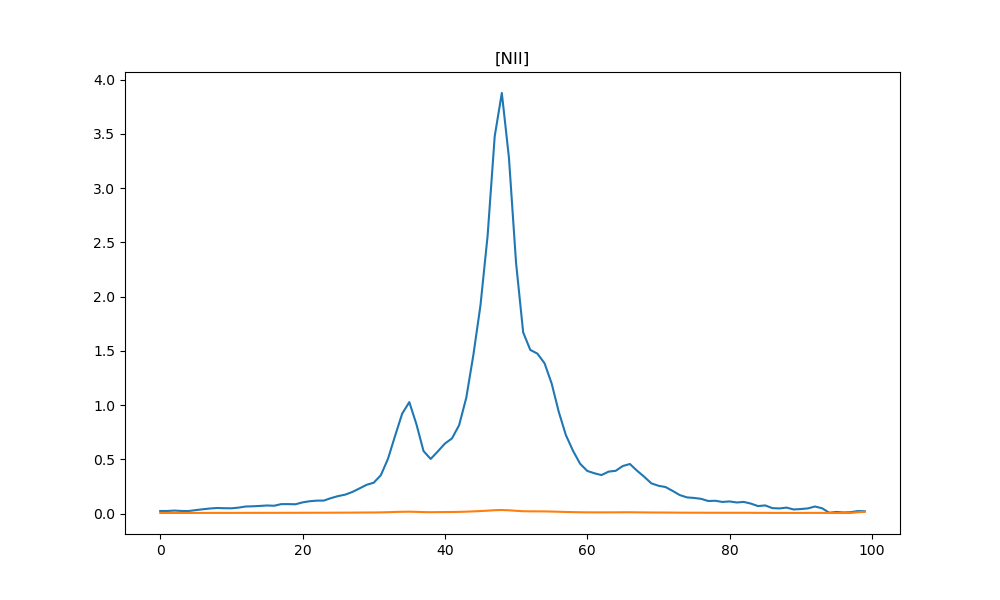

In [56]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [57]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2880.431580039328
differential_evolution step 2: f(x)= 2880.431580039328
differential_evolution step 3: f(x)= 2880.431580039328
differential_evolution step 4: f(x)= 2880.431580039328
differential_evolution step 5: f(x)= 2880.431580039328
differential_evolution step 6: f(x)= 2880.431580039328
differential_evolution step 7: f(x)= 2880.431580039328
differential_evolution step 8: f(x)= 2842.282231121091
differential_evolution step 9: f(x)= 2842.282231121091
differential_evolution step 10: f(x)= 1377.7953205783208
differential_evolution step 11: f(x)= 1258.8217071927738
differential_evolution step 12: f(x)= 916.025660334971
differential_evolution step 13: f(x)= 713.6416806761155
differential_evolution step 14: f(x)= 713.6416806761155
differential_evolution step 15: f(x)= 713.6416806761155
differential_evolution step 16: f(x)= 160.85002944323813
differential_evolution step 17: f(x)= 160.85002944323813
differential_evolution step 18: f(x)= 160.850029443238

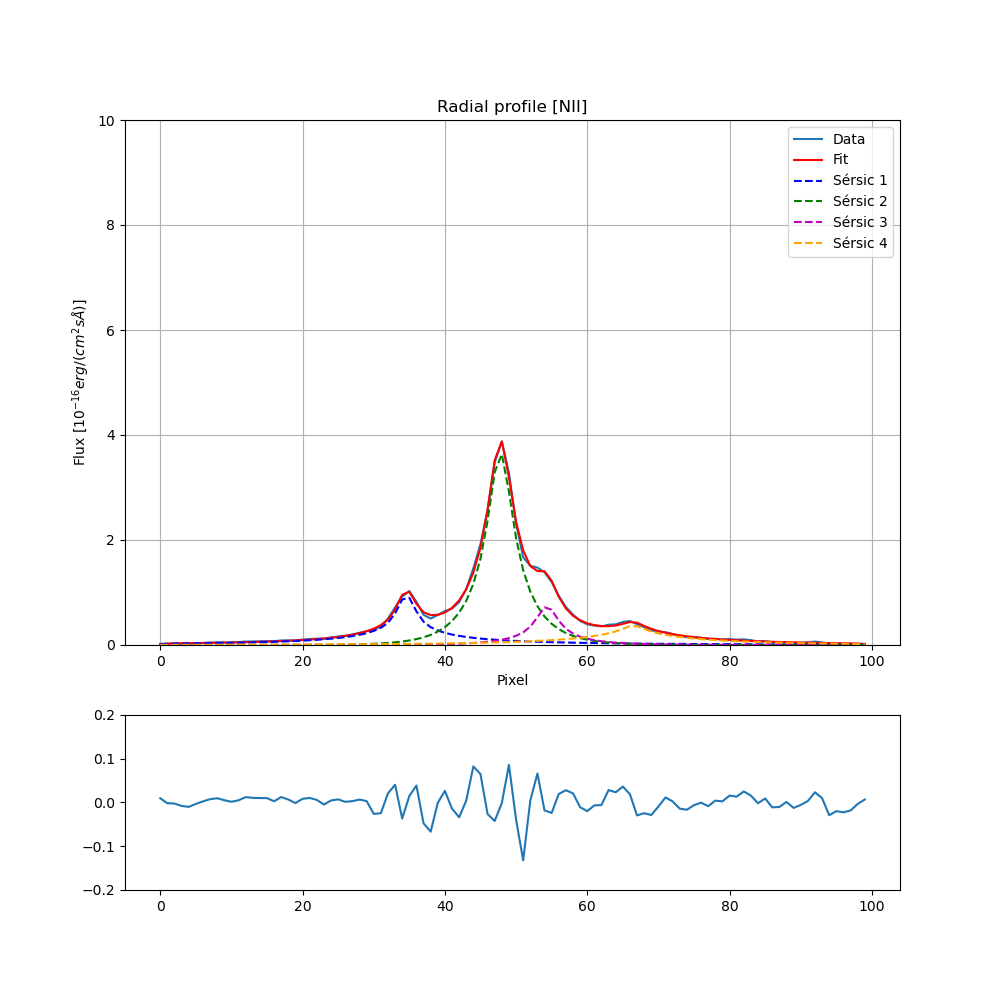

In [58]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [59]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII) #, bounds = bounds_list, maxfev=10000)

chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII,
    x_axes, n_component, line_name="NII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0089, r_e=70.2171, n=3.0595, x_0=34.5647
Sérsic 2: I_e=0.6470, r_e=5.5464, n=1.1885, x_0=47.7572
Sérsic 3: I_e=0.2031, r_e=3.2570, n=0.8932, x_0=54.3810
Sérsic 4: I_e=0.0482, r_e=19.0708, n=1.2818, x_0=65.6431
[3.43809560e-03 2.10886006e+01 2.75600377e-01 5.97723566e-02
 5.13391382e-02 3.27337086e-01 5.74034393e-02 3.25061427e-02
 5.45245884e-02 6.39891056e-01 1.93909545e-01 1.12576336e-01
 8.68506134e-03 2.53711010e+00 1.17972455e-01 2.35079255e-01]
3.775529082779927


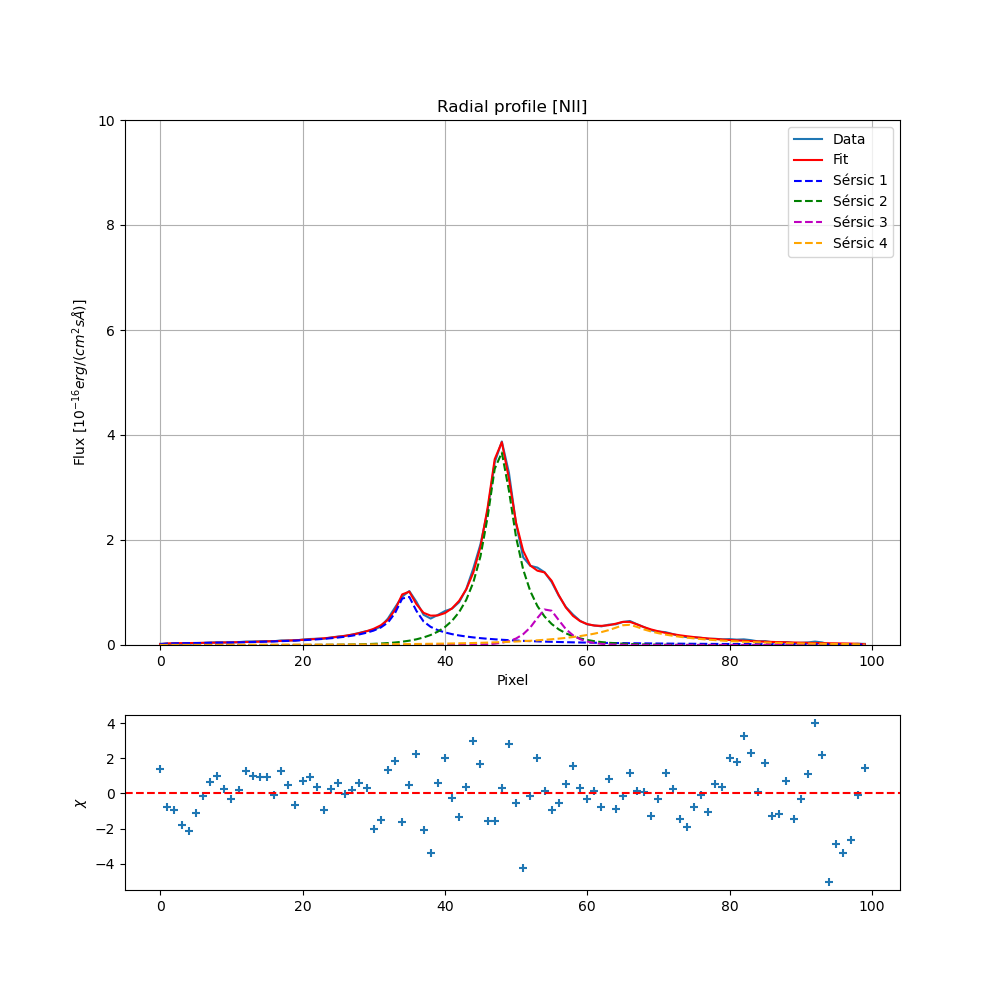

In [60]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

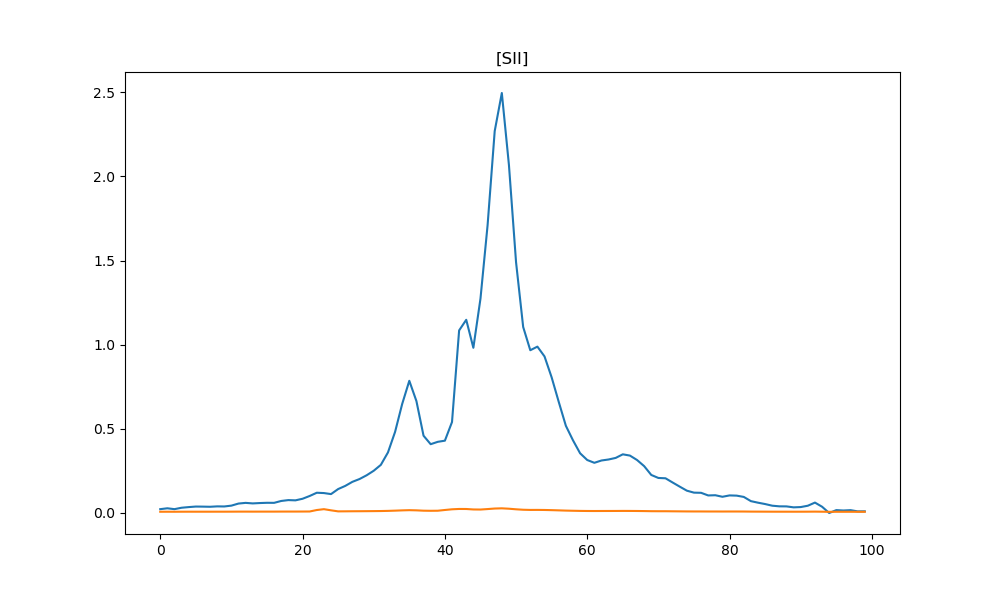

In [61]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [62]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 70074.03182810733
differential_evolution step 2: f(x)= 4844.639024724627
differential_evolution step 3: f(x)= 4844.639024724627
differential_evolution step 4: f(x)= 4844.639024724627
differential_evolution step 5: f(x)= 4844.639024724627
differential_evolution step 6: f(x)= 3553.0721286939015
differential_evolution step 7: f(x)= 424.04109722402336
differential_evolution step 8: f(x)= 424.04109722402336
differential_evolution step 9: f(x)= 424.04109722402336
differential_evolution step 10: f(x)= 424.04109722402336
differential_evolution step 11: f(x)= 424.04109722402336
differential_evolution step 12: f(x)= 424.04109722402336
differential_evolution step 13: f(x)= 424.04109722402336
differential_evolution step 14: f(x)= 424.04109722402336
differential_evolution step 15: f(x)= 424.04109722402336
differential_evolution step 16: f(x)= 424.04109722402336
differential_evolution step 17: f(x)= 424.04109722402336
differential_evolution step 18: f(x)= 54.5969

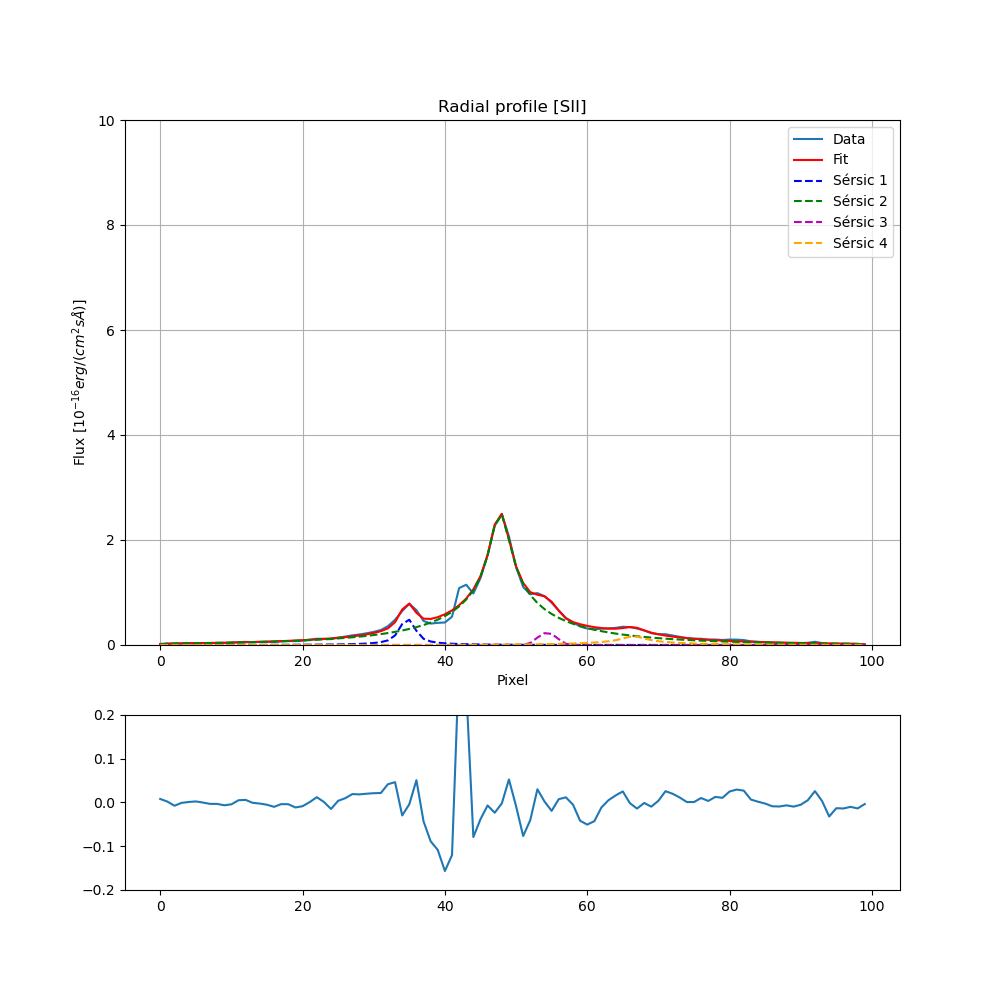

In [63]:
plot_diff(x_axes, best_params, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [64]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII,
    x_axes, n_component, line_name="SII", output_prefix="fit")

Sérsic 1: I_e=0.0031, r_e=41.0855, n=3.7451, x_0=34.6587
Sérsic 2: I_e=0.1090, r_e=21.8858, n=2.0245, x_0=47.7469
Sérsic 3: I_e=0.1907, r_e=1.7631, n=0.0668, x_0=54.3618
Sérsic 4: I_e=0.0175, r_e=18.2247, n=1.4666, x_0=66.3662
[2.67507066e-02 2.88449748e+02 7.37405777e+00 9.45291505e-04
 5.80132505e-02 1.18933665e+01 3.47136692e-01 6.05276206e-02
 3.82274226e+00 8.60473463e+00 1.60562209e+00 2.47609840e-01
 1.19942841e-02 1.43613585e+01 4.72875986e-01 5.32637699e-01]
10.389514731251547


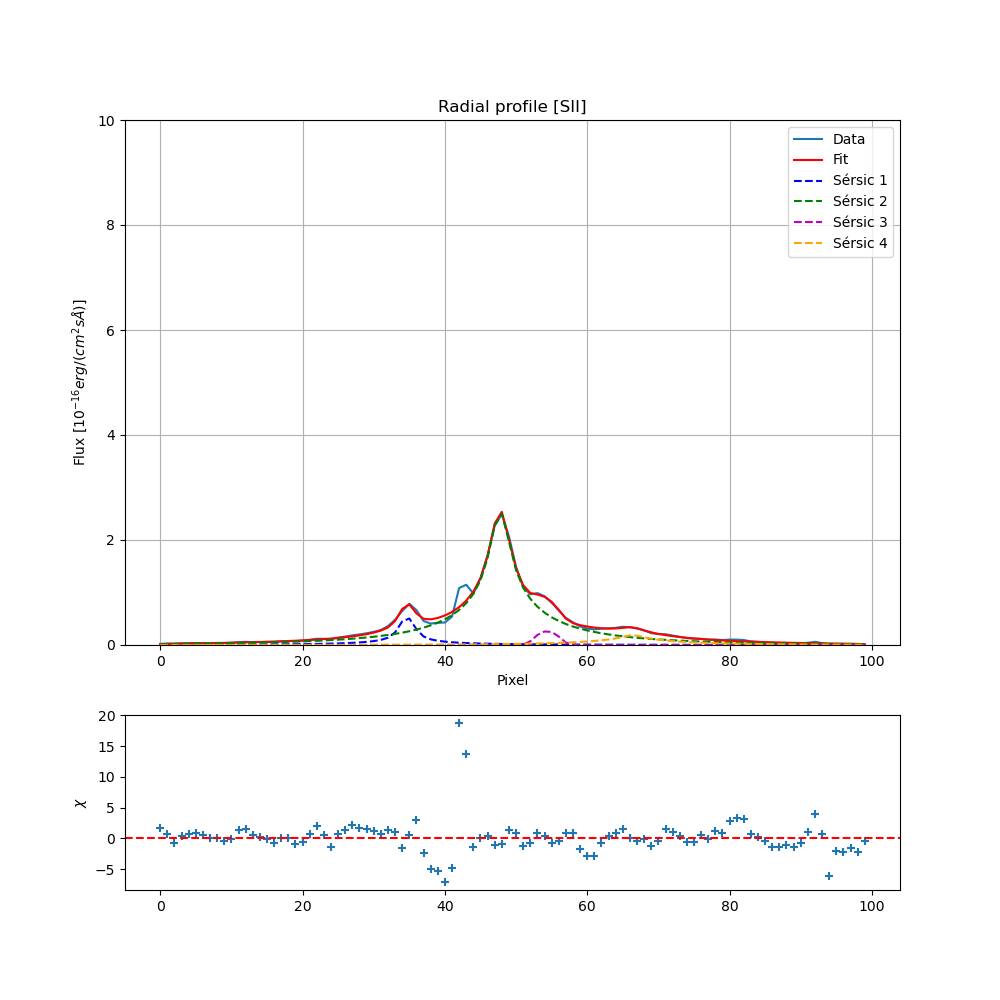

In [65]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

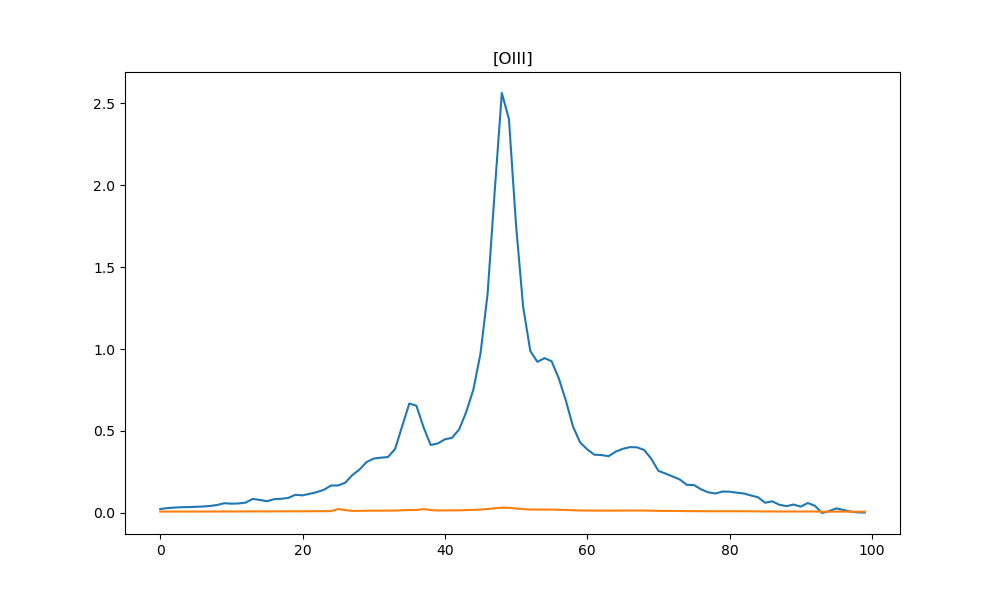

In [66]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [67]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 45610.795771872625
differential_evolution step 2: f(x)= 20217.42272452903
differential_evolution step 3: f(x)= 16148.923187157556
differential_evolution step 4: f(x)= 6744.829831966819
differential_evolution step 5: f(x)= 6744.829831966819
differential_evolution step 6: f(x)= 2581.8817895665975
differential_evolution step 7: f(x)= 2581.8817895665975
differential_evolution step 8: f(x)= 1059.8228249561705
differential_evolution step 9: f(x)= 908.0222095824219
differential_evolution step 10: f(x)= 908.0222095824219
differential_evolution step 11: f(x)= 193.25767915889162
differential_evolution step 12: f(x)= 193.25767915889162
differential_evolution step 13: f(x)= 193.25767915889162
differential_evolution step 14: f(x)= 171.631223749903
differential_evolution step 15: f(x)= 60.2389123640087
differential_evolution step 16: f(x)= 20.396537275025764
differential_evolution step 17: f(x)= 20.396537275025764
differential_evolution step 18: f(x)= 20.39653727

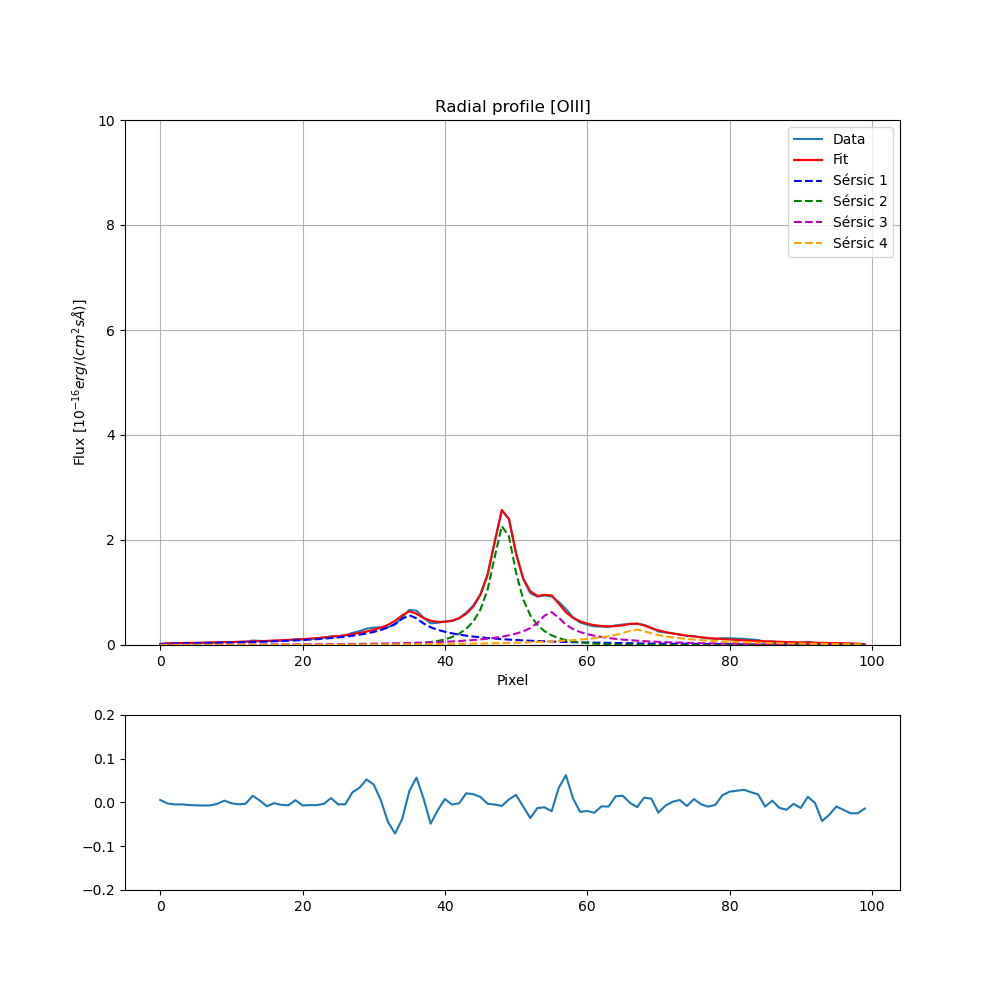

In [68]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [69]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII,
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0351, r_e=32.0648, n=1.7139, x_0=35.2776
Sérsic 2: I_e=0.4169, r_e=4.4307, n=1.2152, x_0=48.2909
Sérsic 3: I_e=0.0371, r_e=14.3902, n=1.8448, x_0=55.1237
Sérsic 4: I_e=0.0458, r_e=17.6900, n=1.1730, x_0=66.7847
[1.01426438e-02 6.88156799e+00 2.25873762e-01 4.59060869e-02
 5.68125399e-02 5.18472488e-01 1.01756235e-01 3.75512164e-02
 5.19812398e-02 2.19838877e+01 9.14936014e-01 1.25107249e-01
 1.36279192e-02 3.53753977e+00 1.38180310e-01 3.80194954e-01]
3.3657821625755715


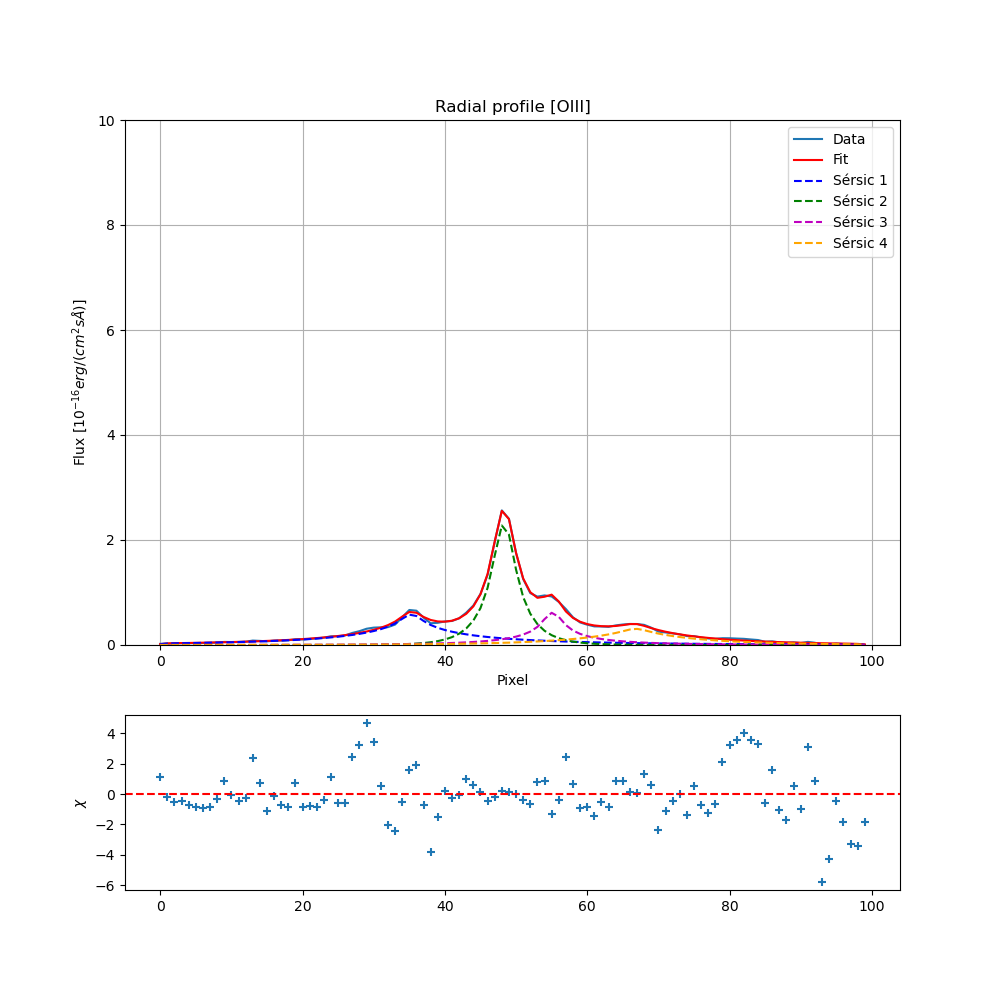

In [70]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

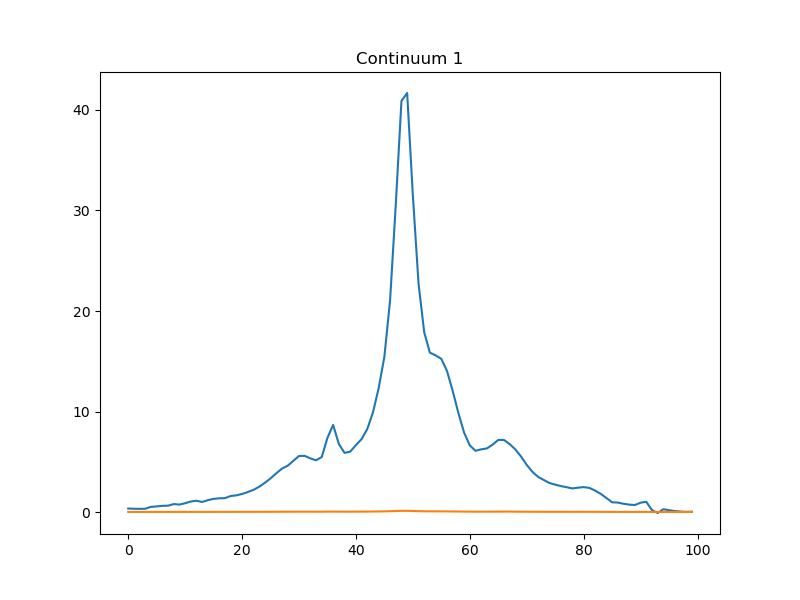

In [71]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [72]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1859.926830968164
differential_evolution step 2: f(x)= 751.8482118986053
differential_evolution step 3: f(x)= 499.717670582709
differential_evolution step 4: f(x)= 499.717670582709
differential_evolution step 5: f(x)= 499.717670582709
differential_evolution step 6: f(x)= 499.717670582709
differential_evolution step 7: f(x)= 368.219650696454
differential_evolution step 8: f(x)= 368.219650696454
differential_evolution step 9: f(x)= 368.219650696454
differential_evolution step 10: f(x)= 276.6873558630312
differential_evolution step 11: f(x)= 276.6873558630312
differential_evolution step 12: f(x)= 268.3245280862608
differential_evolution step 13: f(x)= 183.88834369490078
differential_evolution step 14: f(x)= 183.88834369490078
differential_evolution step 15: f(x)= 183.88834369490078
differential_evolution step 16: f(x)= 183.88834369490078
differential_evolution step 17: f(x)= 183.88834369490078
differential_evolution step 18: f(x)= 166.60558575052448
di

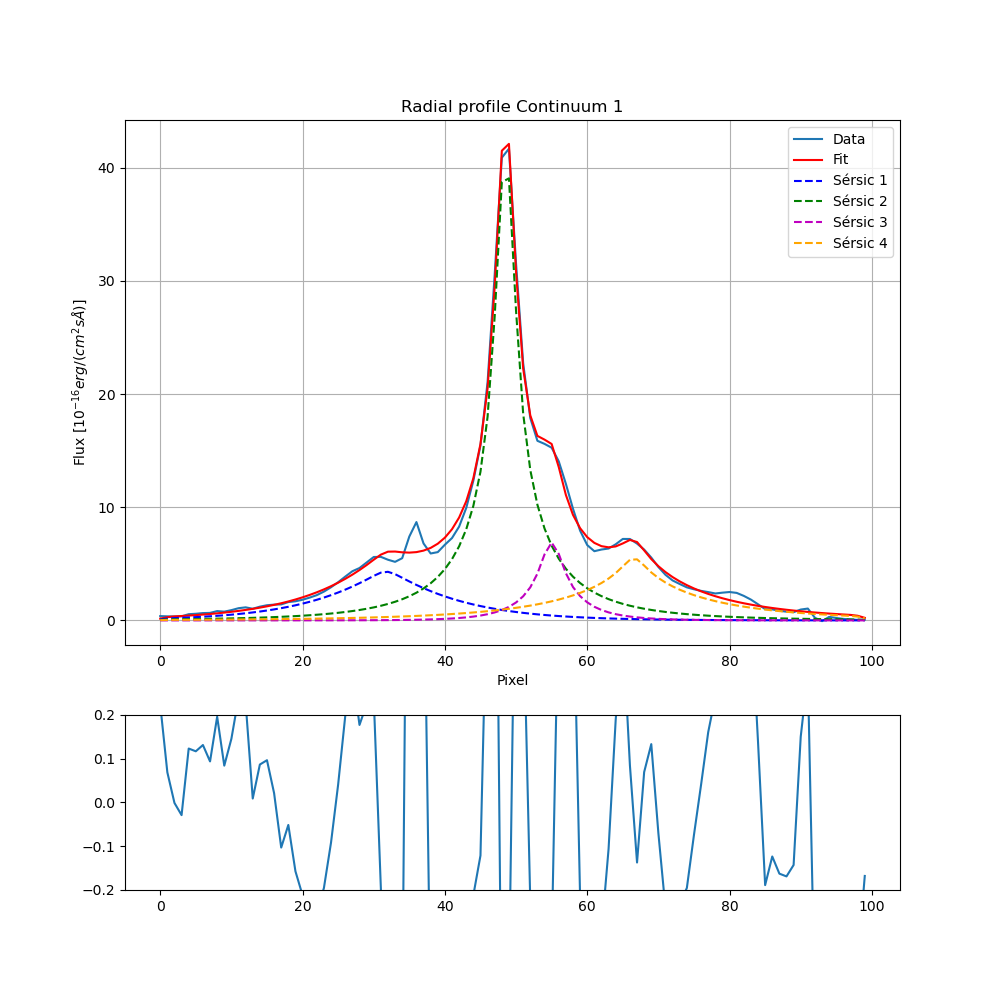

In [74]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [75]:
params_curve_continuum_1, covariance_continuum_1 = curve_fit(model_convolved, x_axes, radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1)

chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1,
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=1.5753, r_e=17.9700, n=0.8647, x_0=35.2085
Sérsic 2: I_e=8.2172, r_e=4.1453, n=1.1012, x_0=48.5208
Sérsic 3: I_e=4.2894, r_e=2.5158, n=0.4994, x_0=55.4301
Sérsic 4: I_e=1.3408, r_e=17.1561, n=0.9874, x_0=65.4059
[0.22150939 1.41466805 0.08163897 0.6339604  1.29204828 0.52326712
 0.11197311 0.0490988  0.97037777 0.39248429 0.16182737 0.17364679
 0.20158943 1.60971248 0.09802434 0.39263295]
45.07466108739103


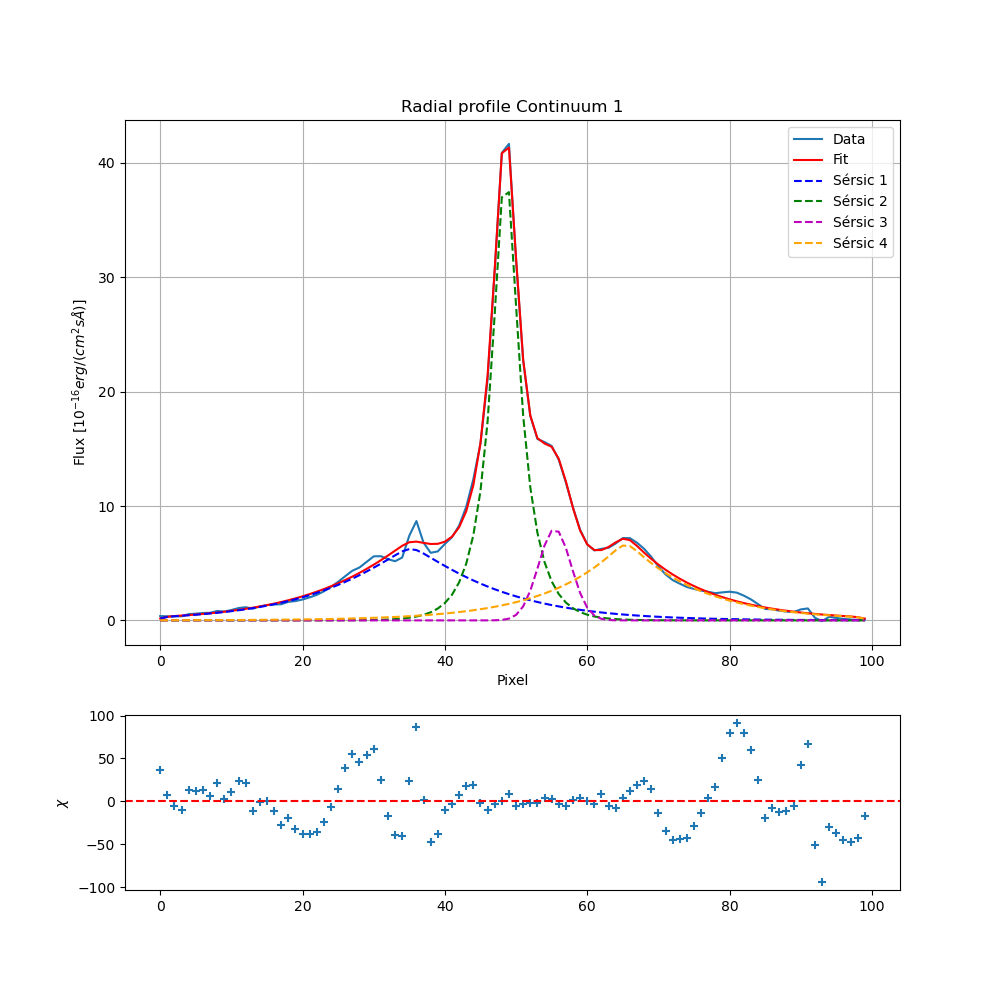

In [76]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

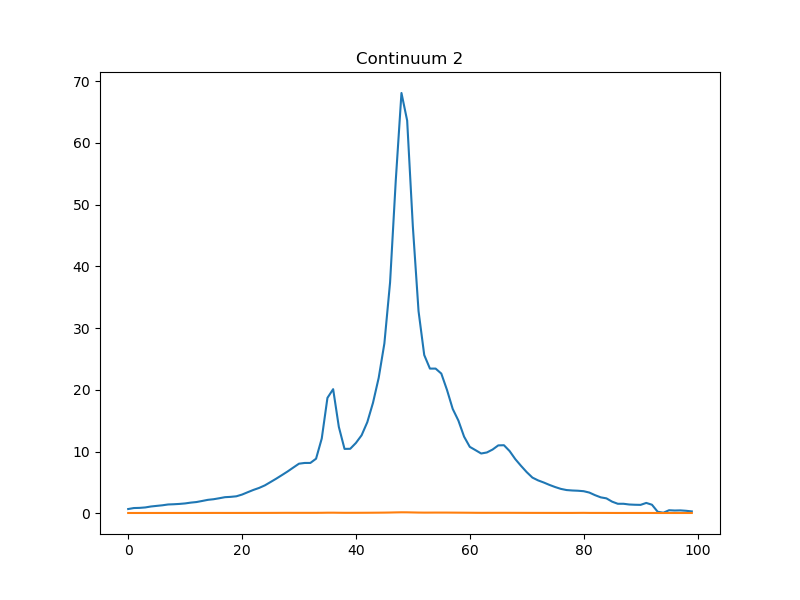

In [77]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [78]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1521.9470104359489
differential_evolution step 2: f(x)= 1521.9470104359489
differential_evolution step 3: f(x)= 1521.9470104359489
differential_evolution step 4: f(x)= 1463.5591175919647
differential_evolution step 5: f(x)= 1463.5591175919647
differential_evolution step 6: f(x)= 1145.3393009228014
differential_evolution step 7: f(x)= 1145.3393009228014
differential_evolution step 8: f(x)= 643.7252682273786
differential_evolution step 9: f(x)= 643.7252682273786
differential_evolution step 10: f(x)= 446.7215481587555
differential_evolution step 11: f(x)= 446.7215481587555
differential_evolution step 12: f(x)= 446.7215481587555
differential_evolution step 13: f(x)= 446.7215481587555
differential_evolution step 14: f(x)= 359.75459429947966
differential_evolution step 15: f(x)= 359.75459429947966
differential_evolution step 16: f(x)= 359.75459429947966
differential_evolution step 17: f(x)= 359.75459429947966
differential_evolution step 18: f(x)= 359.7545

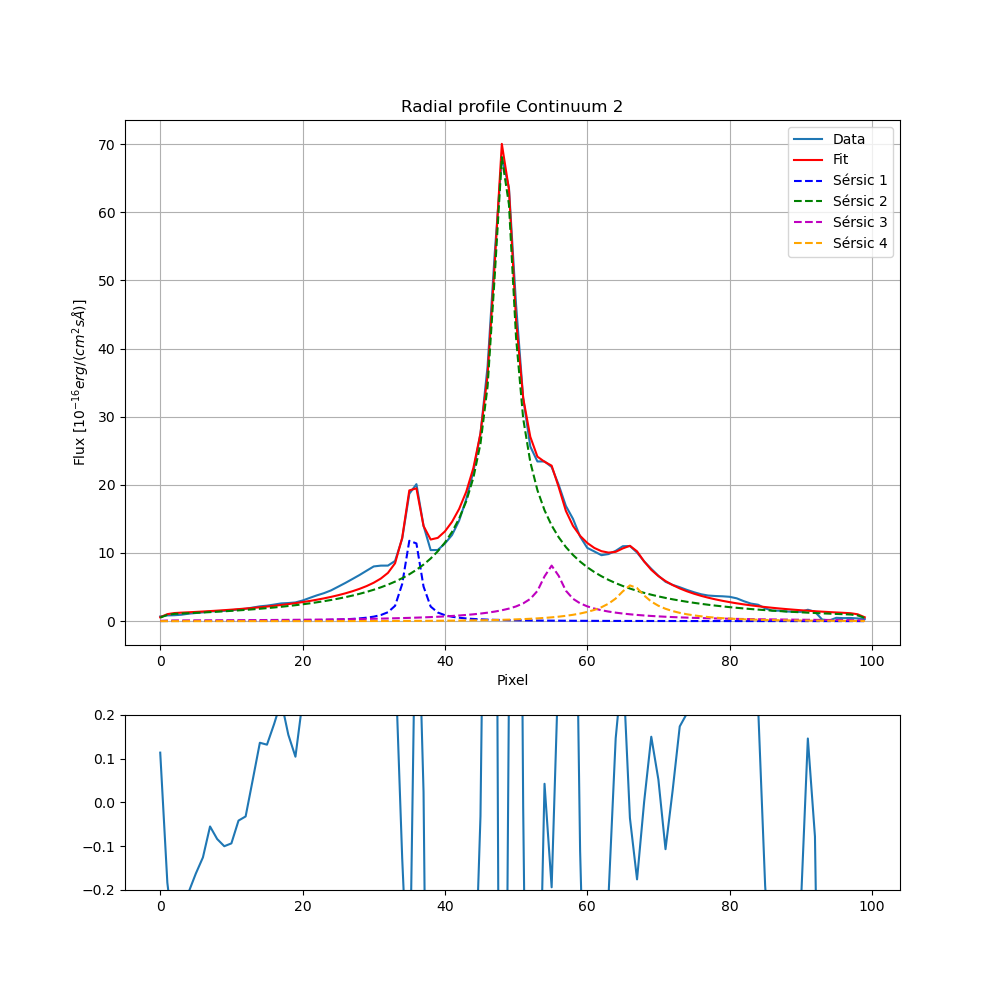

In [80]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
plot_diff(x_axes, best_params, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [81]:
params_curve_continuum_2, covariance_continuum_2 = curve_fit(model_convolved, x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2)#, maxfev=15000)
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
    radial_profile_error_continuum_2, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0790, r_e=34.2508, n=3.7629, x_0=35.4509
Sérsic 2: I_e=0.8721, r_e=51.2258, n=2.8831, x_0=48.2849
Sérsic 3: I_e=0.1064, r_e=34.1384, n=3.0282, x_0=55.2716
Sérsic 4: I_e=0.7786, r_e=11.0005, n=1.2366, x_0=66.2260
[9.55035085e-01 3.13391506e+02 1.07898322e+01 3.08978149e-04
 7.85063347e-01 5.16595280e+01 5.73526606e-01 4.91792169e-02
 1.31981842e+00 4.14546677e+02 8.21340661e+00 2.74847800e-01
 5.97201318e-01 9.86409574e+00 5.36372378e-01 5.01720523e-01]
179.95122260581005


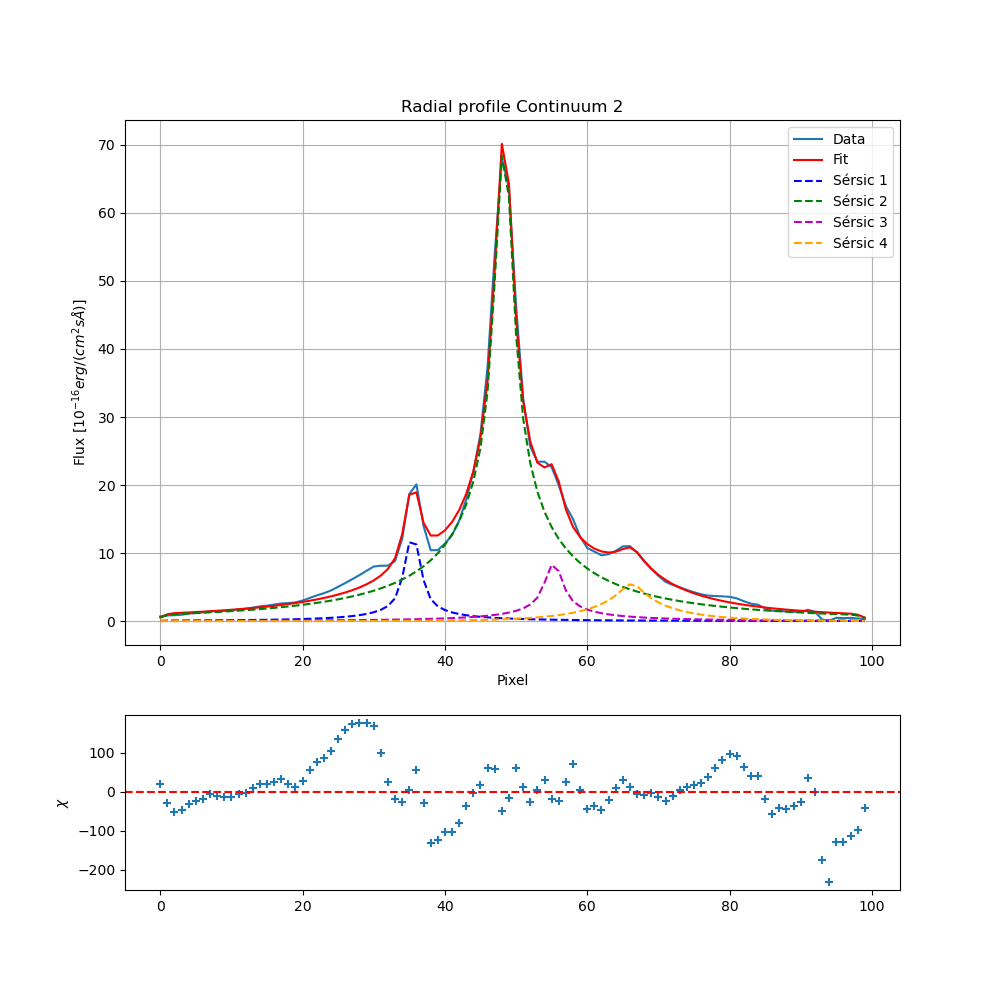

In [82]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

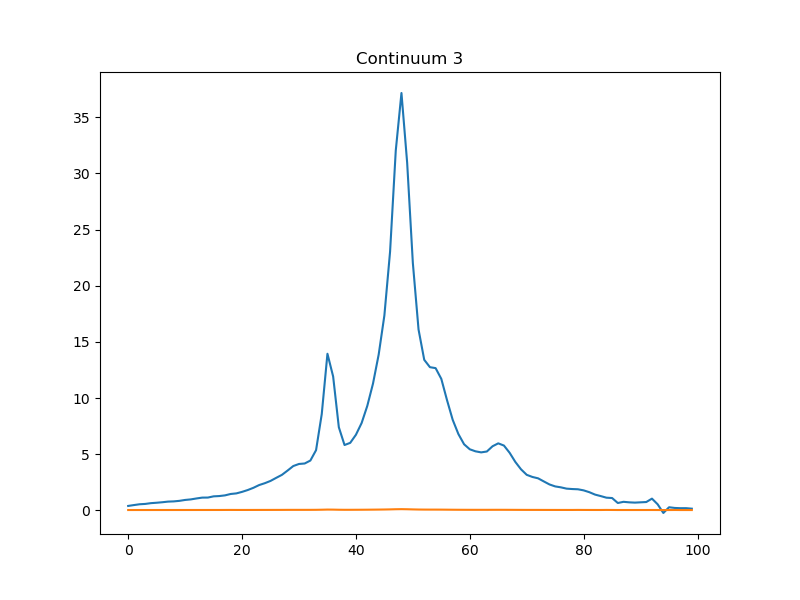

In [83]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [84]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 996.7609151778782
differential_evolution step 2: f(x)= 617.8704737117077
differential_evolution step 3: f(x)= 617.8704737117077
differential_evolution step 4: f(x)= 617.8704737117077
differential_evolution step 5: f(x)= 258.4326894722989
differential_evolution step 6: f(x)= 258.4326894722989
differential_evolution step 7: f(x)= 258.4326894722989
differential_evolution step 8: f(x)= 258.4326894722989
differential_evolution step 9: f(x)= 258.4326894722989
differential_evolution step 10: f(x)= 188.68506728612948
differential_evolution step 11: f(x)= 188.68506728612948
differential_evolution step 12: f(x)= 188.68506728612948
differential_evolution step 13: f(x)= 188.68506728612948
differential_evolution step 14: f(x)= 188.68506728612948
differential_evolution step 15: f(x)= 188.68506728612948
differential_evolution step 16: f(x)= 188.68506728612948
differential_evolution step 17: f(x)= 188.68506728612948
differential_evolution step 18: f(x)= 171.8508845

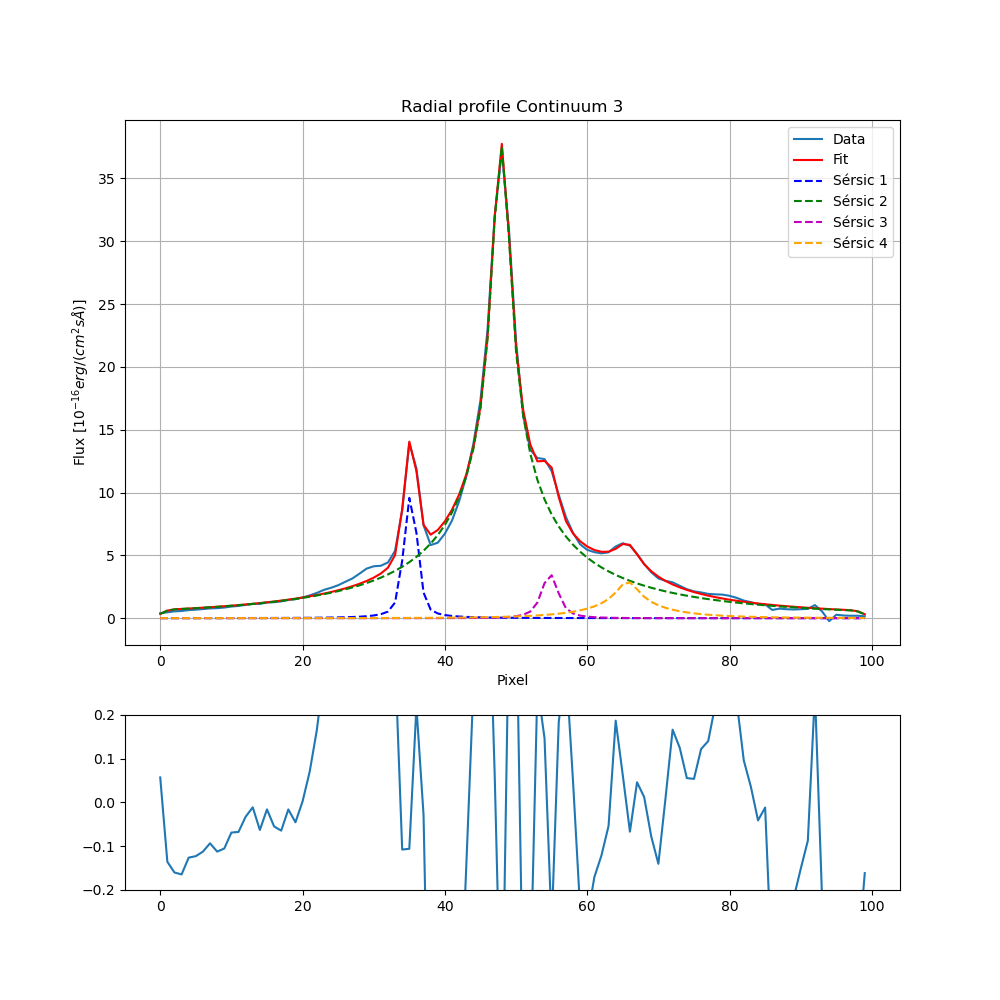

In [85]:
plot_diff(x_axes, best_params, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [86]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(model_convolved, x_axes, radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)

chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
    radial_profile_error_continuum_3, x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15192\1622625359.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0597, r_e=14.3493, n=4.3211, x_0=35.1785
Sérsic 2: I_e=0.6263, r_e=47.3094, n=2.6472, x_0=47.9121
Sérsic 3: I_e=0.5875, r_e=2.6566, n=1.4932, x_0=54.7378
Sérsic 4: I_e=0.3795, r_e=10.0226, n=1.3221, x_0=65.7054
[8.80489507e-01 1.36802879e+02 1.80995106e+01 4.79953243e-04
 1.23485203e-01 8.85888717e+00 1.37720814e-01 4.74119469e-02
 1.54941054e+00 4.65833777e+00 2.07814639e+00 2.25650268e-01
 2.86117963e-01 6.90051258e+00 5.20448975e-01 3.61011946e-01]
90.89566181062204


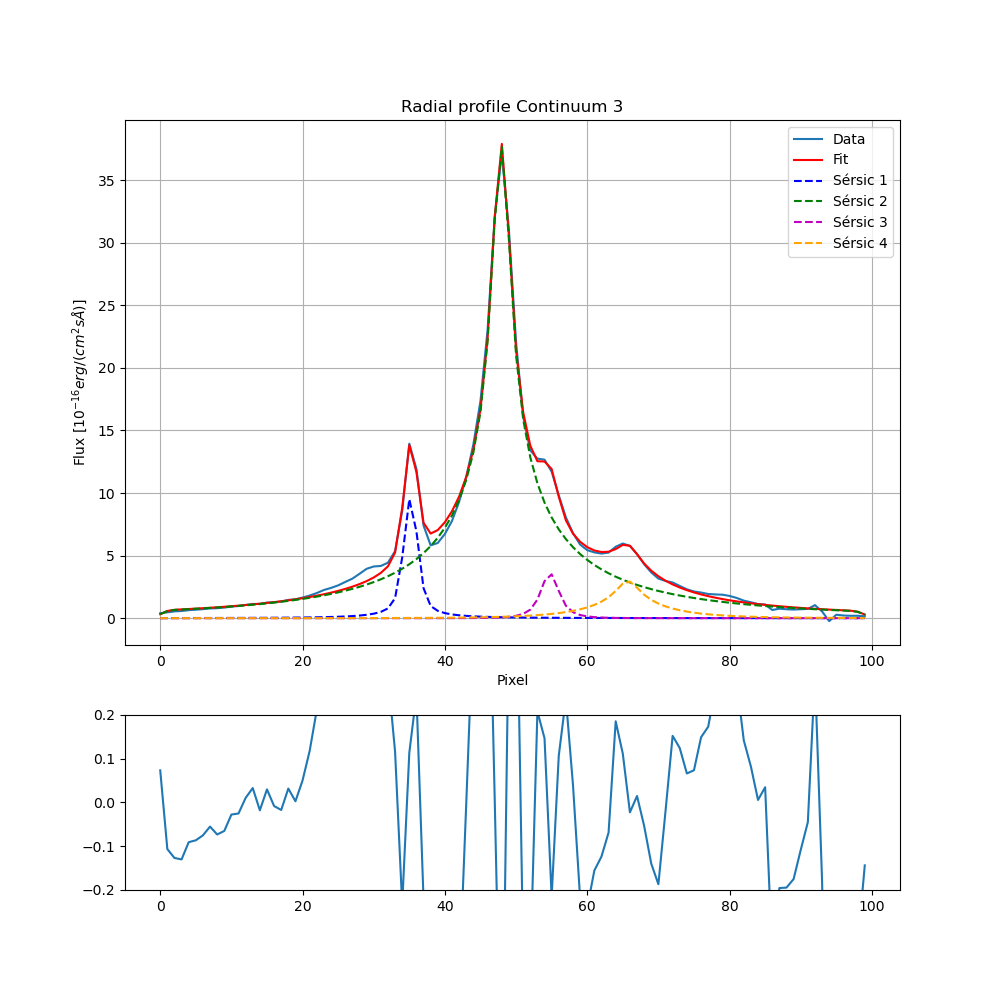

In [87]:
plot_diff(x_axes, params_curve_continuum_3, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [88]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [ ]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
